In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [33]:
    dataset=pd.read_csv("creditcard.csv")


In [34]:
dataset.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
dataset.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [15]:
X = dataset.drop('Class', axis=1)

In [16]:
X.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')

In [17]:
Y = dataset['Class']

In [18]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
model = LogisticRegression(max_iter=10000)

In [13]:
model.fit(X_train , Y_train)
Y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(Y_test , Y_pred)

In [15]:
print("Accuracy:", accuracy)

Accuracy: 0.9991573329588147


In [22]:
from sklearn.metrics import classification_report, confusion_matrix


In [23]:
cm = confusion_matrix(Y_test, Y_pred)
print("confusion_matrix ", cm)

NameError: name 'Y_pred' is not defined

In [18]:
print(classification_report(Y_test, Y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
from imblearn.over_sampling import SMOTE 
sm = SMOTE(random_state=42)
X_train_sm  , Y_train_sm = sm.fit_resample(X_train , Y_train)
model_sm = LogisticRegression(max_iter=10000)
model_sm.fit(X_train_sm, Y_train_sm)
Y_pred_sm = model_sm.predict(X_test)
accuracy01 = accuracy_score(Y_test,  Y_pred_sm)

In [20]:
print("Accuracy:", accuracy01)

Accuracy: 0.990045995575998


In [21]:
cmt=confusion_matrix(Y_test, Y_pred_sm)

In [22]:
print("confusion matrix" , cmt)

confusion matrix [[56307   557]
 [   10    88]]


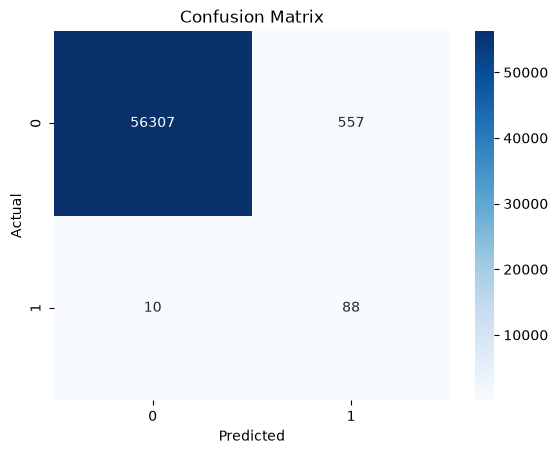

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred_sm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier


In [25]:
rf_model = RandomForestClassifier(random_state=42)

In [26]:
rf_model.fit(X_train_sm , Y_train_sm)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [27]:
f_pred = rf_model.predict(X_test)


In [28]:
accuracy02 = accuracy_score(Y_test,  f_pred)

In [29]:
print("acuuracy" , accuracy02)

acuuracy 0.999420666409185


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(Y_test, f_pred))

print(confusion_matrix(Y_test, f_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

[[56848    16]
 [   17    81]]


In [26]:
from sklearn.metrics import roc_auc_score
roc_auc_score(Y_test, model_sm.predict_proba(X_test)[:,1])

0.9776028447394716

In [25]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline

In [33]:
pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression()),
])

In [34]:
pipe_rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ("model_sm", RandomForestClassifier(random_state=42))
])

In [35]:
pipe.fit(X_train, Y_train)
y_pred_pipe = pipe.predict(X_test)
print(classification_report(Y_test, y_pred_pipe))
print(roc_auc_score(Y_test, pipe.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

0.9708434302252134


In [36]:
pipe_rf.fit(X_train, Y_train)
y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(Y_test, y_pred_rf))
print(roc_auc_score(Y_test, pipe_rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

0.9684509513569075


In [1]:

%store -r


In [2]:

print(X_train.shape)

(227845, 30)


In [3]:
from sklearn.model_selection import GridSearchCV

In [8]:


param_grid = {
    'model_sm__n_estimators': [100],
    'model_sm__max_depth': [10]
}

grid = GridSearchCV(pipe_rf, param_grid, scoring='roc_auc', cv=2, n_jobs=-1)
grid.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model_sm__max_depth': [10], 'model_sm__n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [9]:
print(grid.best_params_)
print(grid.best_score_)

{'model_sm__max_depth': 10, 'model_sm__n_estimators': 100}
0.9822272503736441


In [27]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(Y_test, y_pred_best))
print(roc_auc_score(Y_test, best_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.86      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

0.9827047061086673


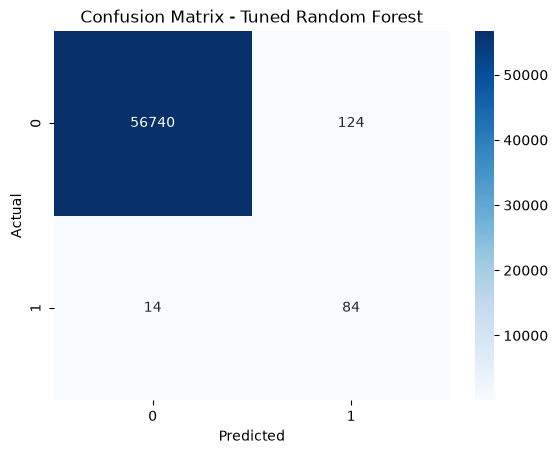

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(Y_test, y_pred_best)

sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [30]:
probs = pipe_rf.predict_proba(X_test)[:,1]
y_pred_lower_threshold = (probs > 0.3).astype(int)  # lowering from default 0.5
print(classification_report(Y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.89      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



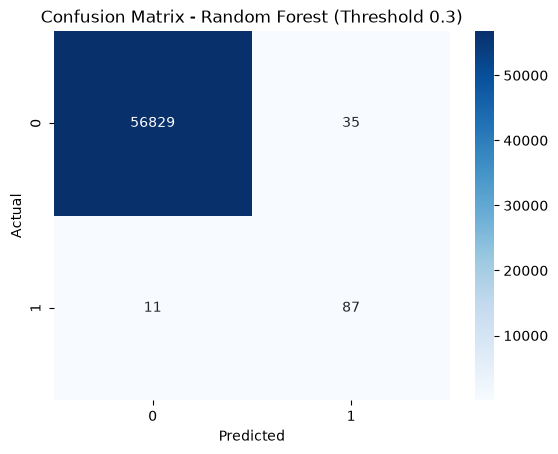

In [31]:
cm_threshold = confusion_matrix(Y_test, y_pred_lower_threshold)

sns.heatmap(cm_threshold, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Threshold 0.3)")
plt.show()

In [37]:
import pandas as pd

new_transaction = pd.DataFrame([{
    'Time': 5000,
    'V1': -1.2, 'V2': 0.5, 'V3': 1.1, 'V4': 0.8, 'V5': -0.3,
    'V6': 0.4, 'V7': -0.9, 'V8': 0.2, 'V9': -1.5, 'V10': 0.6,
    'V11': -0.7, 'V12': 1.3, 'V13': -0.4, 'V14': -2.1, 'V15': 0.9,
    'V16': -0.6, 'V17': -1.8, 'V18': 0.3, 'V19': 0.5, 'V20': -0.2,
    'V21': 0.1, 'V22': 0.4, 'V23': -0.1, 'V24': 0.2, 'V25': 0.3,
    'V26': -0.1, 'V27': 0.05, 'V28': 0.02,
    'Amount': 149.99
}])

prediction = pipe_rf.predict(new_transaction)
probability = pipe_rf.predict_proba(new_transaction)[:,1]

print("Fraud?", prediction)
print("Fraud probability:", probability)


Fraud? [0]
Fraud probability: [0.08]


In [38]:
sample = X_test.iloc[[0]]
prediction = pipe_rf.predict(sample)
probability = pipe_rf.predict_proba(sample)[:,1]

print("Predicted:", prediction)
print("Fraud probability:", probability)
print("Actual answer:", Y_test.iloc[0])

Predicted: [0]
Fraud probability: [0.]
Actual answer: 0


In [40]:
fraud_indices = Y_test[Y_test == 1].index
sample_fraud = X_test.loc[[fraud_indices[0]]]

prediction = pipe_rf.predict(sample_fraud)
probability = pipe_rf.predict_proba(sample_fraud)[:,1]

print("Predicted:", prediction)
print("Fraud probability:", probability)
print("Actual answer:", Y_test.loc[fraud_indices[0]])

Predicted: [1]
Fraud probability: [0.99]
Actual answer: 1


## Conclusion

This project built a fraud detection pipeline on a highly imbalanced credit card 
transaction dataset (~0.17% fraud). A baseline Logistic Regression model achieved 
99.8% accuracy, but this was misleading — it barely caught any fraud cases, 
demonstrating why accuracy is not a suitable metric for imbalanced classification.

After applying SMOTE to balance the training data, both Logistic Regression and 
Random Forest were trained and evaluated using Precision, Recall, and ROC-AUC. 
Logistic Regression achieved high recall (0.92) but extremely poor precision (0.06), 
making it impractical due to excessive false alarms. The untuned Random Forest 
pipeline offered a much stronger balance (precision 0.87, recall 0.83, ROC-AUC 0.968).

Hyperparameter tuning via GridSearchCV (max_depth=10, n_estimators=100) improved 
ROC-AUC slightly to 0.983, but reduced precision significantly (0.40), showing 
that optimizing for ROC-AUC alone doesn't guarantee the best real-world tradeoff.

Adjusting the classification threshold on the untuned Random Forest (from 0.5 to 0.3) 
produced the best overall balance — precision 0.71, recall 0.89 — outperforming the 
tuned model on both precision and F1-score. This shows threshold tuning can be a 
more direct lever than hyperparameter tuning for controlling the precision-recall 
tradeoff in imbalanced classification problems.

**Final recommendation:** the untuned Random Forest pipeline, with a lowered 
classification threshold of 0.3, offers the best practical performance for 
deployment — catching the majority of fraud cases while keeping false alarms 
manageable.